# Logistic Regression — Heart Disease Prediction
**Module:** IT5052 – Fundamentals of Machine Learning  
**Program:** MSc in Artificial Intelligence, SLIIT (2026)  

This notebook continues from the preprocessing pipeline.  
Pre-split, pre-scaled data is loaded from `output/csv/`.

## 1. Import Libraries

In [1]:
# Standard libs
import os
from pathlib import Path
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Model
from sklearn.linear_model import LogisticRegression

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay
)

# Tuning
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Save model
import joblib

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries loaded successfully")

Libraries loaded successfully


## 2. Define Paths

In [2]:
BASE_DIR = Path(os.getcwd()).parent

DATA_DIR  = BASE_DIR / "output" / "csv"
MODEL_DIR = BASE_DIR / "output" / "model"
METRIC_DIR = BASE_DIR / "output" / "metrics"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
METRIC_DIR.mkdir(parents=True, exist_ok=True)

print("DATA_DIR :", DATA_DIR)
print("MODEL_DIR:", MODEL_DIR)
print("METRIC_DIR:", METRIC_DIR)

DATA_DIR : C:\MSc - AI\Semester - 01\IT5022 - Fundamentals of Machine Learning\Assignment\Machine-Learning-Programming-Assignment-IT5052\output\csv
MODEL_DIR: C:\MSc - AI\Semester - 01\IT5022 - Fundamentals of Machine Learning\Assignment\Machine-Learning-Programming-Assignment-IT5052\output\model
METRIC_DIR: C:\MSc - AI\Semester - 01\IT5022 - Fundamentals of Machine Learning\Assignment\Machine-Learning-Programming-Assignment-IT5052\output\metrics


## 3. Load Pre-processed Data

In [3]:
X_train = pd.read_csv(DATA_DIR / "X_train.csv")
X_test  = pd.read_csv(DATA_DIR / "X_test.csv")
y_train = pd.read_csv(DATA_DIR / "y_train.csv").squeeze()
y_test  = pd.read_csv(DATA_DIR / "y_test.csv").squeeze()

print("Train shape:", X_train.shape)
print("Test  shape:", X_test.shape)
print("\nClass distribution (train):")
print(y_train.value_counts())

Train shape: (8000, 20)
Test  shape: (2000, 20)

Class distribution (train):
Heart Disease Status
0    6387
1    1613
Name: count, dtype: int64


## 4. Data Validation

In [4]:
assert not X_train.isnull().any().any(), "Missing values in X_train"
assert not X_test.isnull().any().any(),  "Missing values in X_test"
assert len(X_train) == len(y_train),     "Row mismatch in training data"
assert len(X_test)  == len(y_test),      "Row mismatch in test data"

print("Data validation passed")
print("\nFeatures:", list(X_train.columns))

Data validation passed

Features: ['Age', 'Gender', 'Blood Pressure', 'Cholesterol Level', 'Exercise Habits', 'Smoking', 'Family Heart Disease', 'Diabetes', 'BMI', 'High Blood Pressure', 'Low HDL Cholesterol', 'High LDL Cholesterol', 'Alcohol Consumption', 'Stress Level', 'Sleep Hours', 'Sugar Consumption', 'Triglyceride Level', 'Fasting Blood Sugar', 'CRP Level', 'Homocysteine Level']


## 5. Baseline Logistic Regression

We use `class_weight='balanced'` to handle class imbalance in the dataset.

In [5]:
baseline_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=RANDOM_STATE
)

baseline_model.fit(X_train, y_train)

y_pred_base = baseline_model.predict(X_test)
y_prob_base = baseline_model.predict_proba(X_test)[:, 1]

acc_base = accuracy_score(y_test, y_pred_base)
auc_base = roc_auc_score(y_test, y_prob_base)

print(f"Baseline Accuracy : {acc_base:.4f}")
print(f"Baseline ROC-AUC  : {auc_base:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_base))

Baseline Accuracy : 0.5065
Baseline ROC-AUC  : 0.4890

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.51      0.63      1613
           1       0.19      0.49      0.28       387

    accuracy                           0.51      2000
   macro avg       0.50      0.50      0.45      2000
weighted avg       0.69      0.51      0.56      2000



## 6. Hyperparameter Tuning (GridSearchCV)

We search over regularization strength `C` and penalty type, using 5-fold stratified cross-validation.

In [6]:
param_grid = {
    "C":       [0.01, 0.1, 1, 10, 100],
    "penalty": ["l2"],
    "solver":  ["lbfgs"]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    estimator=LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=RANDOM_STATE
    ),
    param_grid=param_grid,
    cv=cv,
    scoring="roc_auc",
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV ROC-AUC :", round(grid_search.best_score_, 4))

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best Parameters: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV ROC-AUC : 0.4891


## 7. Best Model Evaluation

In [7]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
roc_auc  = roc_auc_score(y_test, y_prob)

print(f"Accuracy : {accuracy:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy : 0.5065
ROC-AUC  : 0.4890

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.51      0.63      1613
           1       0.19      0.49      0.28       387

    accuracy                           0.51      2000
   macro avg       0.50      0.50      0.45      2000
weighted avg       0.69      0.51      0.56      2000



## 8. Confusion Matrix

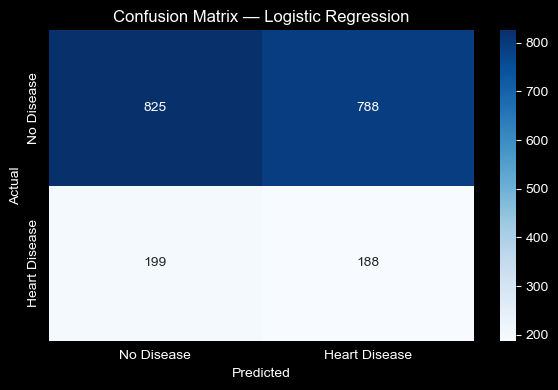

Confusion Matrix:
 [[825 788]
 [199 188]]


In [8]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Heart Disease'],
            yticklabels=['No Disease', 'Heart Disease'])
plt.title("Confusion Matrix — Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

print("Confusion Matrix:\n", cm)

## 9. ROC Curve

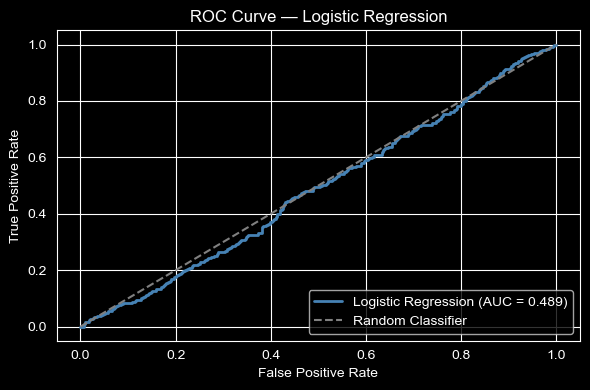

In [9]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='steelblue', lw=2,
         label=f"Logistic Regression (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Classifier')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Logistic Regression")
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 10. Feature Coefficients (Interpretability)

Logistic Regression coefficients show the direction and magnitude of each feature's influence on the prediction.

C:\Users\seyon\AppData\Local\Temp\ipykernel_42484\727659461.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=coefficients,


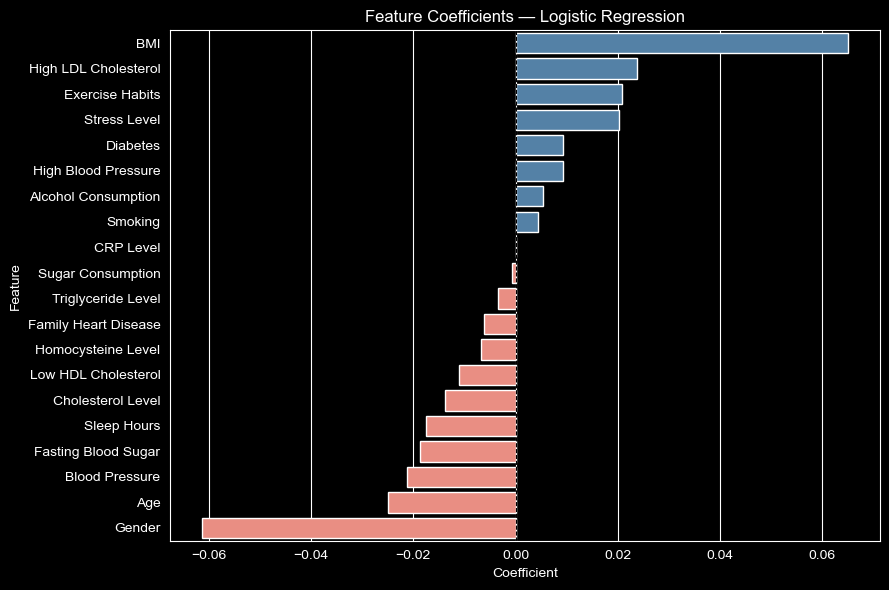

             Feature  Coefficient
                 BMI     0.064990
High LDL Cholesterol     0.023856
     Exercise Habits     0.020913
        Stress Level     0.020168
            Diabetes     0.009268
 High Blood Pressure     0.009259
 Alcohol Consumption     0.005415
             Smoking     0.004374
           CRP Level     0.000172
   Sugar Consumption    -0.000754
  Triglyceride Level    -0.003440
Family Heart Disease    -0.006209
  Homocysteine Level    -0.006724
 Low HDL Cholesterol    -0.011140
   Cholesterol Level    -0.013757
         Sleep Hours    -0.017568
 Fasting Blood Sugar    -0.018651
      Blood Pressure    -0.021192
                 Age    -0.025025
              Gender    -0.061252


In [10]:
coefficients = pd.DataFrame({
    'Feature':     X_train.columns,
    'Coefficient': best_model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(9, 6))
colors = ['steelblue' if c > 0 else 'salmon' for c in coefficients['Coefficient']]
sns.barplot(x='Coefficient', y='Feature', data=coefficients,
            palette=colors, orient='h')
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.title("Feature Coefficients — Logistic Regression")
plt.tight_layout()
plt.show()

print(coefficients.to_string(index=False))

## 11. Save Metrics

In [11]:
metrics = {
    "model":    "logistic_regression",
    "accuracy": round(accuracy, 4),
    "roc_auc":  round(roc_auc, 4)
}

metrics_df = pd.DataFrame([metrics])
metrics_path = METRIC_DIR / "lr_metrics.csv"
metrics_df.to_csv(metrics_path, index=False)

print("Metrics saved to:", metrics_path)
print(metrics_df)

Metrics saved to: C:\MSc - AI\Semester - 01\IT5022 - Fundamentals of Machine Learning\Assignment\Machine-Learning-Programming-Assignment-IT5052\output\metrics\lr_metrics.csv
                 model  accuracy  roc_auc
0  logistic_regression    0.5065    0.489


## 12. Save Model

In [12]:
model_path = MODEL_DIR / "logistic_regression_model.pkl"
joblib.dump(best_model, model_path)

print("Model saved to:", model_path)

Model saved to: C:\MSc - AI\Semester - 01\IT5022 - Fundamentals of Machine Learning\Assignment\Machine-Learning-Programming-Assignment-IT5052\output\model\logistic_regression_model.pkl


## 13. Save Predictions

In [13]:
pred_df = pd.DataFrame({
    "y_true": y_test.values,
    "y_pred": y_pred,
    "y_prob": y_prob
})

pred_path = METRIC_DIR / "lr_predictions.csv"
pred_df.to_csv(pred_path, index=False)

print("Predictions saved to:", pred_path)
print(pred_df.head())

Predictions saved to: C:\MSc - AI\Semester - 01\IT5022 - Fundamentals of Machine Learning\Assignment\Machine-Learning-Programming-Assignment-IT5052\output\metrics\lr_predictions.csv
   y_true  y_pred    y_prob
0       0       1  0.517869
1       0       1  0.516995
2       0       0  0.486652
3       0       1  0.534742
4       0       0  0.471025


## Summary

| Step | Detail |
|------|--------|
| Model | Logistic Regression (`class_weight='balanced'`) |
| Tuning | GridSearchCV over `C` ∈ {0.01, 0.1, 1, 10, 100}, 5-fold Stratified CV |
| Scoring | ROC-AUC (better for imbalanced classes than accuracy) |
| Outputs | `logistic_regression_model.pkl`, `lr_metrics.csv`, `lr_predictions.csv` |